In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

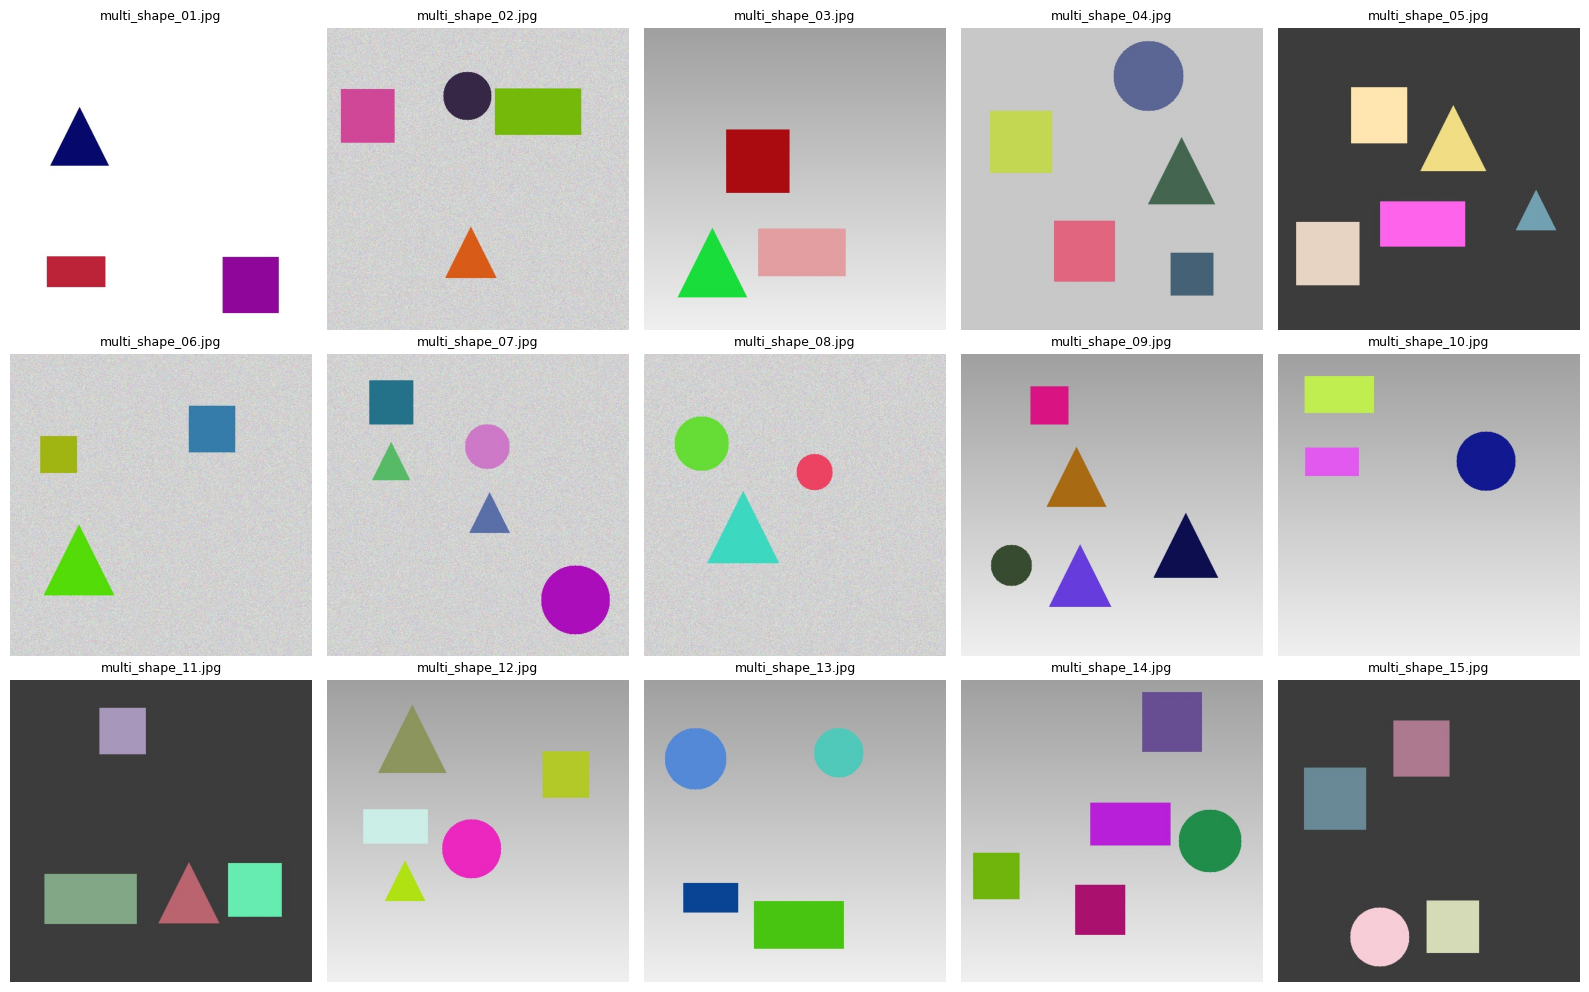

In [12]:
import glob
import matplotlib.pyplot as plt

image_paths = sorted(glob.glob("multi_shape_dataset/*.jpg"))

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for ax, path in zip(axes.ravel(), image_paths):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
import glob

image_paths = sorted(glob.glob("multi_shape_dataset/*.jpg"))


test_images = image_paths[:10]

print("Testing images:")
for img in test_images:
    print(img)

Testing images:
multi_shape_dataset/multi_shape_01.jpg
multi_shape_dataset/multi_shape_02.jpg
multi_shape_dataset/multi_shape_03.jpg
multi_shape_dataset/multi_shape_04.jpg
multi_shape_dataset/multi_shape_05.jpg
multi_shape_dataset/multi_shape_06.jpg
multi_shape_dataset/multi_shape_07.jpg
multi_shape_dataset/multi_shape_08.jpg
multi_shape_dataset/multi_shape_09.jpg
multi_shape_dataset/multi_shape_10.jpg


In [15]:
for index, path in enumerate(test_images, 1):

    print("Processing:", path)

    # Read image
    image = cv2.imread(path)

    original = image.copy()


    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


    # Apply threshold
    _, thresh = cv2.threshold(
        gray,
        150,
        255,
        cv2.THRESH_BINARY_INV
    )


    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print("Total Contours:", len(contours))


    # Draw contours
    contour_img = image.copy()

    cv2.drawContours(
        contour_img,
        contours,
        -1,
        (0,255,0),
        3
    )


    # Shape detection
    shape_img = image.copy()


    for contour in contours:

        area = cv2.contourArea(contour)

        # Ignore small noise
        if area < 500:
            continue


        perimeter = cv2.arcLength(contour, True)

        approx = cv2.approxPolyDP(
            contour,
            0.03 * perimeter,
            True
        )


        corners = len(approx)


        x, y, w, h = cv2.boundingRect(contour)


        # Identify shape
        if corners == 3:
            shape = "Triangle"

        elif corners == 4:

            ratio = w / h

            if 0.9 <= ratio <= 1.1:
                shape = "Square"
            else:
                shape = "Rectangle"

        else:
            shape = "Circle"



        print(shape)


        # Draw rectangle
        cv2.rectangle(
            shape_img,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )


        # Write shape name
        cv2.putText(
            shape_img,
            shape,
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,0,0),
            2
        )


    # Save outputs

    cv2.imwrite(
        f"{original_folder}/original_{index}.jpg",
        original
    )

    cv2.imwrite(
        f"{contour_folder}/contours_{index}.jpg",
        contour_img
    )

    cv2.imwrite(
        f"{shape_folder}/shapes_{index}.jpg",
        shape_img
    )


print("All images processed successfully!")

Processing: multi_shape_dataset/multi_shape_01.jpg
Total Contours: 3
Square
Rectangle
Triangle
Processing: multi_shape_dataset/multi_shape_02.jpg
Total Contours: 4
Triangle
Square
Rectangle
Circle
Processing: multi_shape_dataset/multi_shape_03.jpg
Total Contours: 2
Triangle
Square
Processing: multi_shape_dataset/multi_shape_04.jpg
Total Contours: 4
Square
Square
Triangle
Circle
Processing: multi_shape_dataset/multi_shape_05.jpg
Total Contours: 1
Square
Processing: multi_shape_dataset/multi_shape_06.jpg
Total Contours: 13
Square
Processing: multi_shape_dataset/multi_shape_07.jpg
Total Contours: 21
Circle
Triangle
Triangle
Square
Processing: multi_shape_dataset/multi_shape_08.jpg
Total Contours: 1
Circle
Processing: multi_shape_dataset/multi_shape_09.jpg
Total Contours: 5
Triangle
Circle
Triangle
Triangle
Square
Processing: multi_shape_dataset/multi_shape_10.jpg
Total Contours: 2
Rectangle
Circle
All images processed successfully!


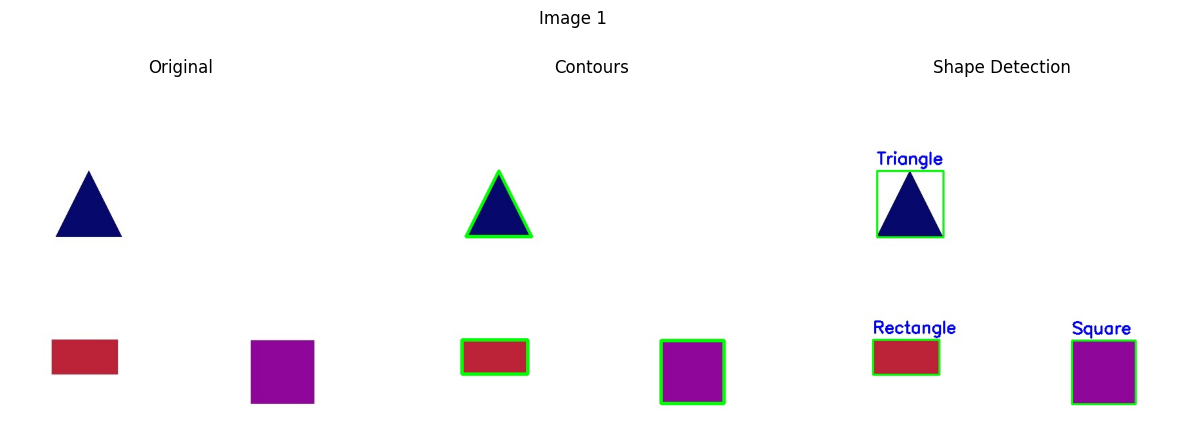

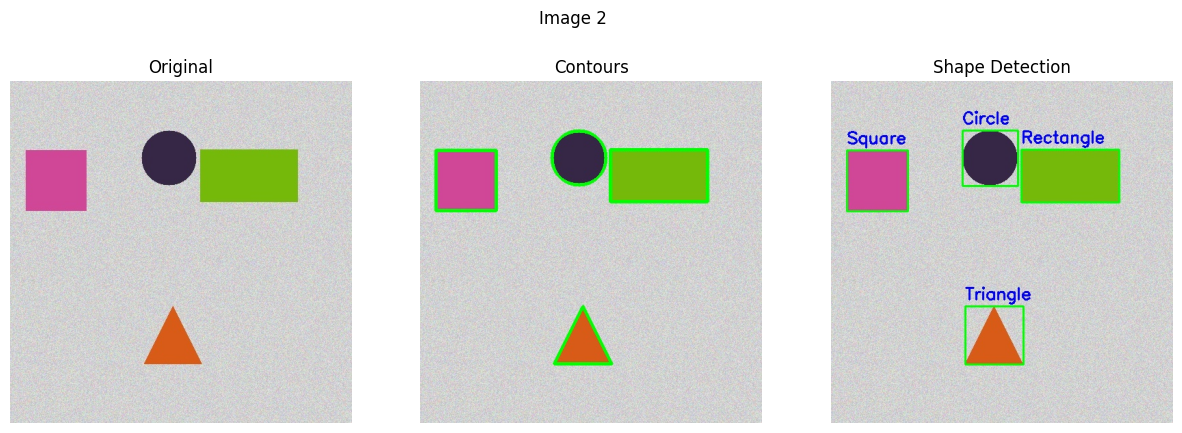

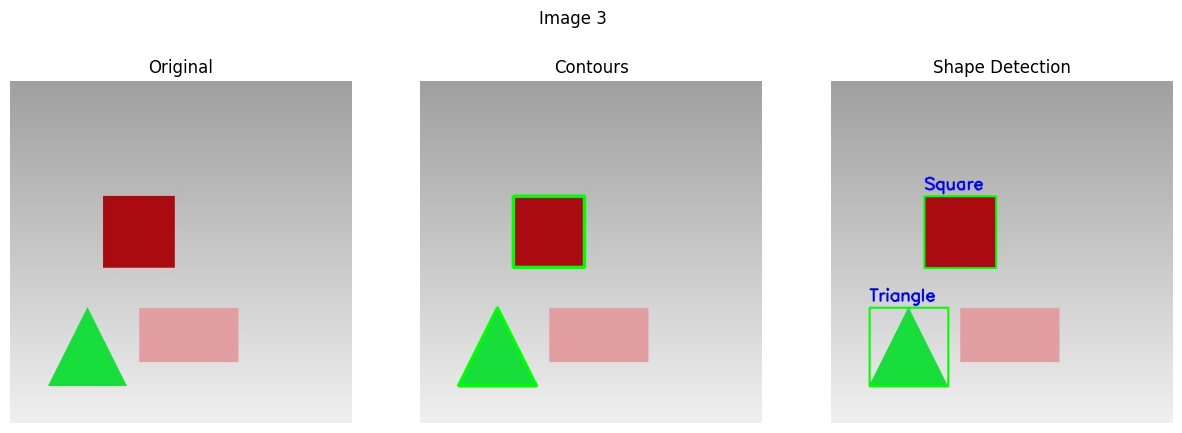

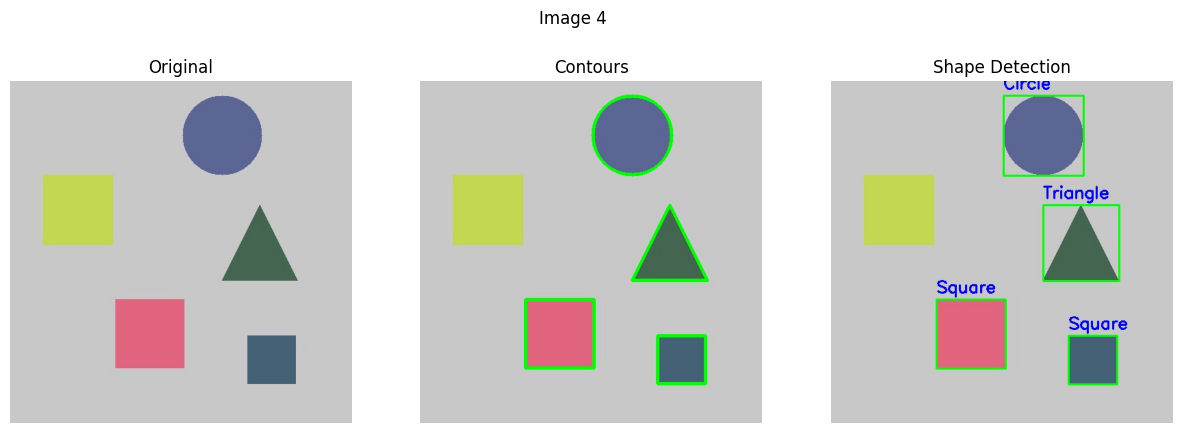

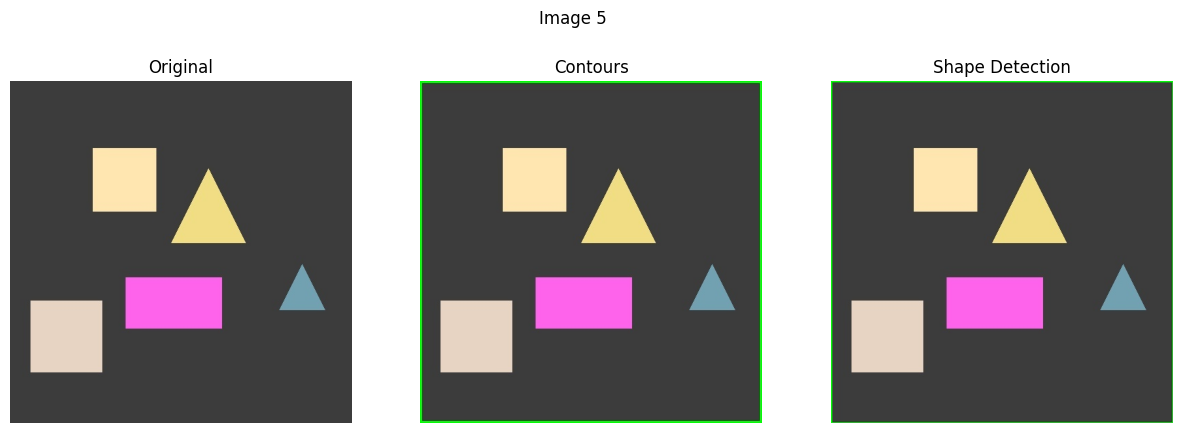

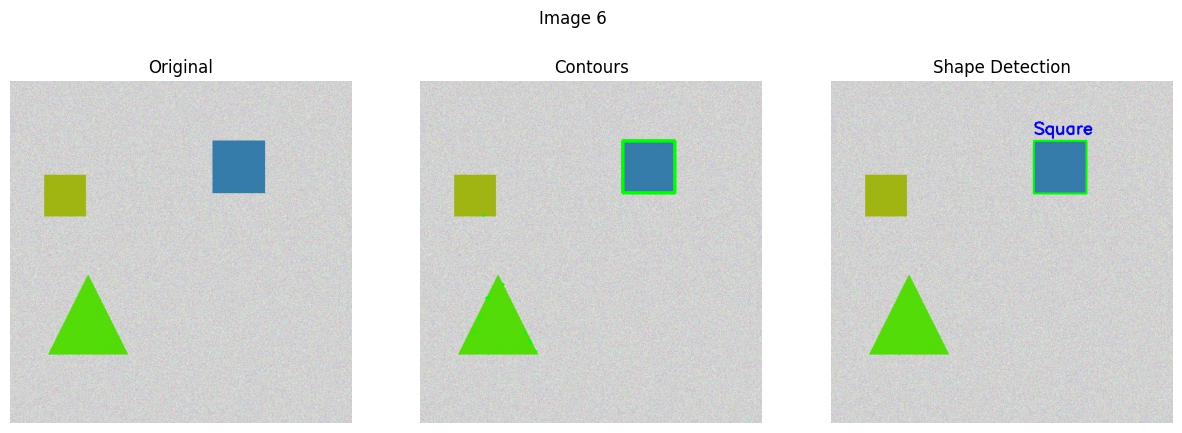

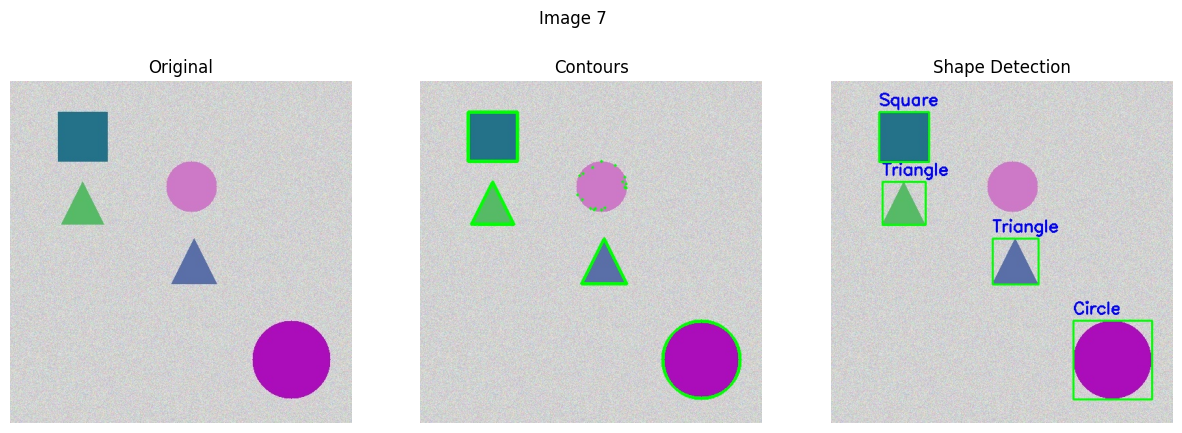

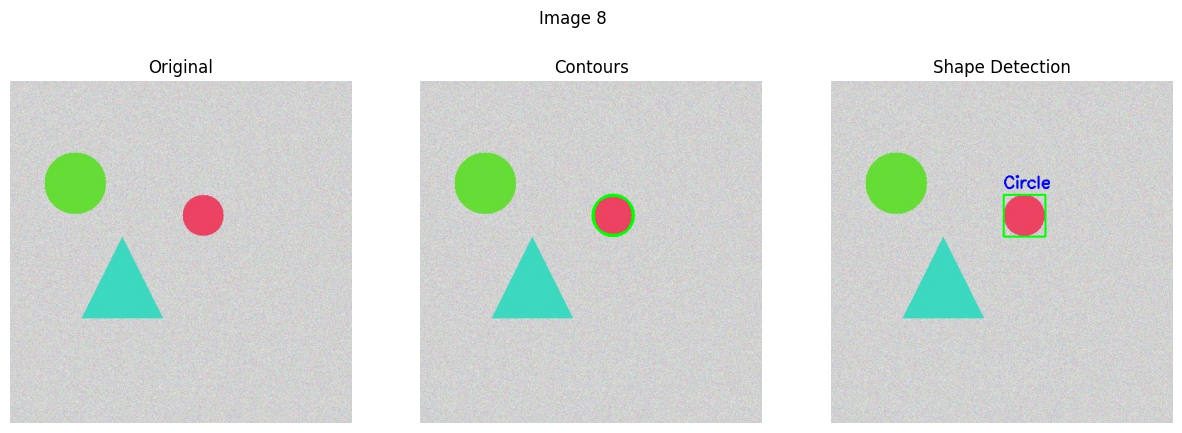

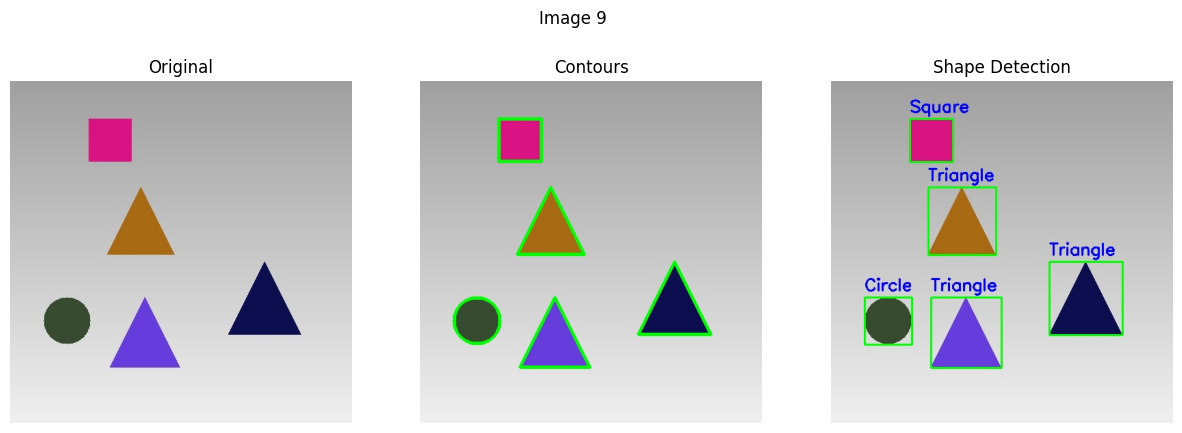

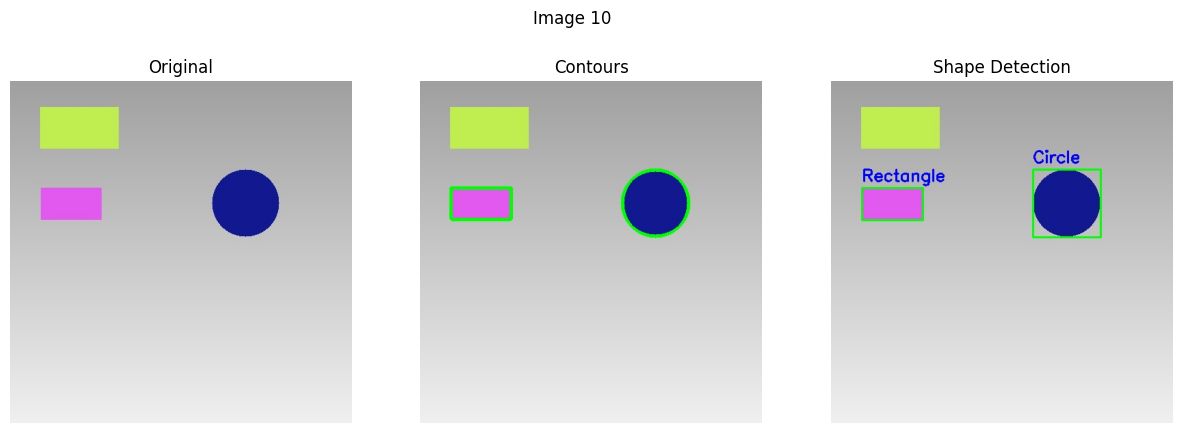

In [16]:
import matplotlib.pyplot as plt


for i in range(1,11):

    original = cv2.imread(
        f"{original_folder}/original_{i}.jpg"
    )

    contour = cv2.imread(
        f"{contour_folder}/contours_{i}.jpg"
    )

    shape = cv2.imread(
        f"{shape_folder}/shapes_{i}.jpg"
    )


    images = [
        original,
        contour,
        shape
    ]

    titles = [
        "Original",
        "Contours",
        "Shape Detection"
    ]


    plt.figure(figsize=(15,5))


    for j in range(3):

        plt.subplot(1,3,j+1)

        img_rgb = cv2.cvtColor(
            images[j],
            cv2.COLOR_BGR2RGB
        )

        plt.imshow(img_rgb)
        plt.title(titles[j])
        plt.axis("off")


    plt.suptitle(f"Image {i}")
    plt.show()